"Rancangan Sistem Klasifikasi AI untuk Memprediksi Status Jejak Karbon Individu Berdasarkan Pola Konsumsi Harian"

In [18]:
import pandas as pd

Upload Dataset:

In [19]:
df = pd.read_csv ('Carbon Emission.csv')

Cleaning dan Preprocessing:

In [20]:
# melihat jumlah nilai null padaa dataset
df.isnull().sum()

Body Type                           0
Sex                                 0
Diet                                0
How Often Shower                    0
Heating Energy Source               0
Transport                           0
Vehicle Type                     6721
Social Activity                     0
Monthly Grocery Bill                0
Frequency of Traveling by Air       0
Vehicle Monthly Distance Km         0
Waste Bag Size                      0
Waste Bag Weekly Count              0
How Long TV PC Daily Hour           0
How Many New Clothes Monthly        0
How Long Internet Daily Hour        0
Energy efficiency                   0
Recycling                           0
Cooking_With                        0
CarbonEmission                      0
dtype: int64

In [21]:
# melihat jumlah data yang duplikat pada dataset
df.duplicated().sum()

np.int64(0)

In [22]:
# mengubah seluruh nilai null pada kolom 'Vehicle Type' menjadi 'Unknown'
df['Vehicle Type'] = df['Vehicle Type'].fillna('Unknown') 

In [23]:
# mengubah seluruh format data ke numerical
df['CarbonEmission'] = pd.to_numeric (df['CarbonEmission'], errors= 'coerce')

In [24]:
df = df.dropna() # pembersihan ulang (just in case)

In [25]:
# menghitung median sebagai acuan nilai tengah untuk mengidentifikasi status emisi, rendah emisi (0) dan tinggi emisi (1)
median_emisi = df['CarbonEmission'].median()

In [26]:
# menentukan status emisi
def tentukan_status(nilai_emisi):
    if nilai_emisi > median_emisi:
        return 1
    else:
        return 0

df['Status_Emisi'] = df['CarbonEmission'].apply(tentukan_status)

In [27]:
# mengubah data teks biasa menjadi numerical pada kolom 'How Often Shower'
df['How Often Shower'] = df['How Often Shower'].astype('category')
kategori_shower = df['How Often Shower'].cat.categories.tolist()
df['How Often Shower'] = df['How Often Shower'].cat.codes

Exploratory Data Analysis (EDA):

In [28]:
df.describe()

,How Often Shower,Monthly Grocery Bill,Vehicle Monthly Distance Km,Waste Bag Weekly Count,How Long TV PC Daily Hour,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission,Status_Emisi
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.493700,173.875200,2031.485900,4.024600,12.139200,25.109000,11.889100,2269.147300,0.499600
std,1.123604,72.234018,2769.715597,1.990375,7.106369,14.698725,7.277218,1017.675247,0.500025
min,0.000000,50.000000,0.000000,1.000000,0.000000,0.000000,0.000000,306.000000,0.000000
25%,0.000000,111.000000,69.000000,2.000000,6.000000,13.000000,6.000000,1538.000000,0.000000
50%,1.000000,173.000000,823.000000,4.000000,12.000000,25.000000,12.000000,2080.000000,0.000000
75%,3.000000,237.000000,2516.750000,6.000000,18.000000,38.000000,18.000000,2768.000000,1.000000
max,3.000000,299.000000,9999.000000,7.000000,24.000000,50.000000,24.000000,8377.000000,1.000000


In [29]:
df['Status_Emisi'].value_counts()

Status_Emisi
0    5004
1    4996
Name: count, dtype: int64

In [30]:
kolom_eda = ['Vehicle Monthly Distance Km', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour', 'CarbonEmission']
df[kolom_eda].corr()

,Vehicle Monthly Distance Km,How Many New Clothes Monthly,How Long Internet Daily Hour,CarbonEmission
Vehicle Monthly Distance Km,1.000000,0.004934,-0.003497,0.594171
How Many New Clothes Monthly,0.004934,1.000000,0.006426,0.198887
How Long Internet Daily Hour,-0.003497,0.006426,1.000000,0.043878
CarbonEmission,0.594171,0.198887,0.043878,1.000000


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6824\3037803485.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Status_Emisi', data=df, palette='Set2')


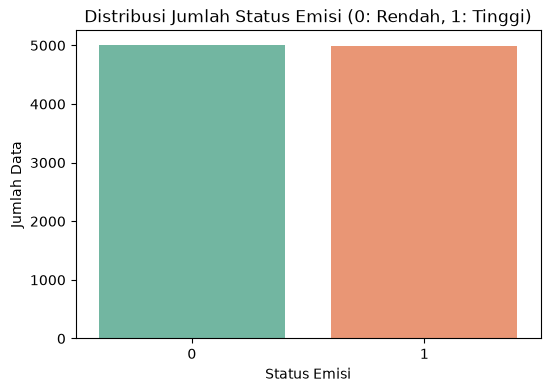

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik diagram batang
plt.figure(figsize=(6,4))
sns.countplot(x='Status_Emisi', data=df, palette='Set2')
plt.title('Distribusi Jumlah Status Emisi (0: Rendah, 1: Tinggi)')
plt.xlabel('Status Emisi')
plt.ylabel('Jumlah Data')
plt.show()

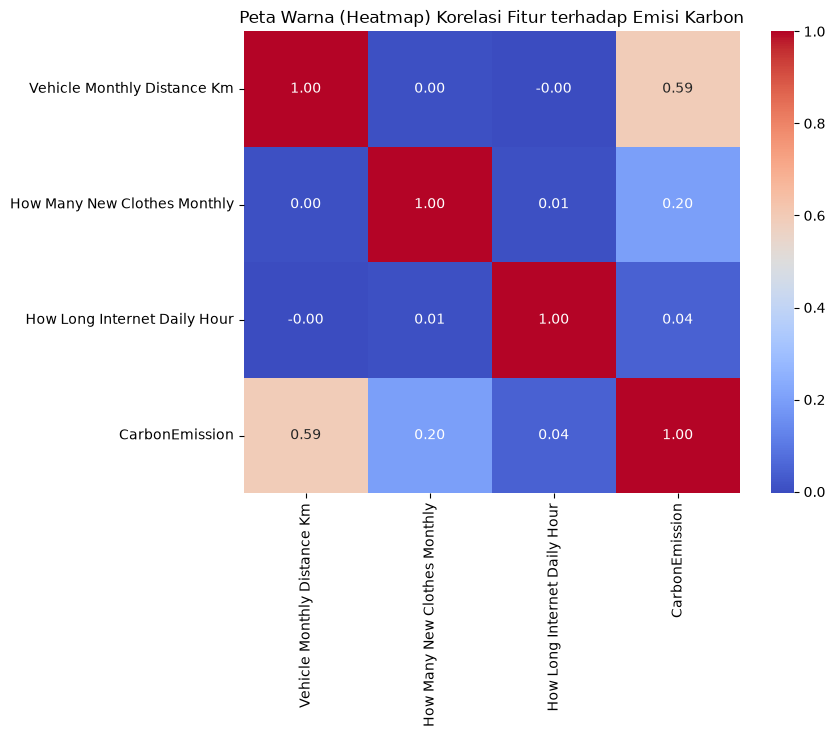

In [32]:
# Membuat grafik peta warna korelasi
plt.figure(figsize=(8,6))
sns.heatmap(df[kolom_eda].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Peta Warna (Heatmap) Korelasi Fitur terhadap Emisi Karbon')
plt.show()

FEATURE SELECTION:

In [33]:
# Menentukan Fitur (X) dan Target (Y) untuk model AI
X = df[['How Often Shower', 'Vehicle Monthly Distance Km', 'How Many New Clothes Monthly', 'How Long Internet Daily Hour']] #fitur input
Y = df['Status_Emisi'] #target tebakan

TRAIN - Test Split:

In [34]:
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

PEMODELAN

In [ ]:
#Algoritma 1: Decision Tree Classifier 
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(max_depth=3, random_state=1)
model_dt.fit(X_train, Y_train)

In [ ]:
#Algoritma 2: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=1)
model_rf.fit(X_train, Y_train)

EVALUASI MODEL - membandingkan akurasi

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#menyuruh kedua model menebah data testing
prediksi_dt = model_dt.predict(X_test)
prediksi_rf = model_rf.predict(X_test)

#menghitung persentase kebenaran tebakan
akurasi_dt = accuracy_score(Y_test, prediksi_dt)
akurasi_rf = accuracy_score(Y_test, prediksi_rf)

In [ ]:
print("="*50)
print(f" AKURASI ALGORITMA 1 (Decision Tree) : {akurasi_dt * 100:.2f}%")
print(f" AKURASI ALGORITMA 2 (Random Forest) : {akurasi_rf * 100:.2f}%")
print("="*50)

#menampilkan detail laporan performa
print("\n[INFO] Laporan Detail Klasifikasi Decision Tree:")
print(classification_report(Y_test, prediksi_dt))

print("\n[INFO] Laporan Detail Klasifikasi Random Forest:")
print(classification_report(Y_test, prediksi_rf))

PREDIKSI & INTERPRETASI

In [ ]:
# ========================================================
# TAHAP 8 & 9: PREDIKSI INTERAKTIF, INTERPRETASI, & AKURASI LIVE
# ========================================================
import pandas as pd

print("\n" + "="*55)
print("   SISTEM AI PREDIKSI STATUS JEJAK KARBON INDIVIDU   ")
print("="*55)
print("Silakan lihat daftar pilihan opsi mandi kamu:")
for i, opsi in enumerate(kategori_shower):
    print(f" [{i}] {opsi}")

try:
    # --- INPUT DATA USER ---
    input_shower = int(input(f"\nMasukkan nomor opsi mandi (0 sampai {len(kategori_shower)-1}): "))
    
    if input_shower < 0 or input_shower >= len(kategori_shower):
        print(f"\n[Error] Opsi mandi tidak valid! Pilih angka 0 sampai {len(kategori_shower)-1}.\n")
    else:
        input_jarak = float(input("Masukkan jarak tempuh kendaraan per bulan (km): "))
        input_baju = int(input("Masukkan jumlah baju baru yang dibeli per bulan (pcs): "))
        input_internet = float(input("Masukkan durasi internetan per hari (jam): "))

        # Menyusun data input menjadi format tabel dataframe
        data_user = pd.DataFrame([[input_shower, input_jarak, input_baju, input_internet]], columns=X.columns)

        # AI melakukan prediksi berbasis model Random Forest terbaik
        hasil_prediksi = model_rf.predict(data_user)

        # --- TAHAP 8 & 9: HASIL PREDIKSI, INTERPRETASI & TINGKAT AKURASI ---
        print("\n" + "="*55)
        print("HASIL PREDIKSI & INTERPRETASI AI KELOMPOK:")
        print("="*55)
        
        if hasil_prediksi == 1:
            print(" >> STATUS EMISI ANDA: TINGGI (Berbahaya bagi Lingkungan) <<")
            print(f" [Tingkat Kepercayaan/Akurasi Prediksi: {akurasi_rf * 100:.2f}%]") # Menampilkan akurasi di sini! ✨
            
            print("\n[Interpretasi Data]:")
            print(f" Gaya hidup Anda menghasilkan emisi di atas batas median nilai tengah.")
            print(f" Faktor kontribusi terbesar didorong oleh mobilitas kendaraan pribadi ({input_jarak} km/bulan)")
            print(f" serta konsumsi pakaian baru sebanyak ({input_baju} pcs/bulan).")
            print("\n[Tahap 9: Rekomendasi Solusi]:")
            print(" 1. Kurangi penggunaan kendaraan pribadi, beralihlah ke angkutan umum/sepeda.")
            print(" 2. Batasi pembelian baju baru (hindari tren fast fashion yang boros energi).")
        else:
            print(" >> STATUS EMISI ANDA: RENDAH (Bagus dan Ramah Lingkungan) <<")
            print(f" [Tingkat Kepercayaan/Akurasi Prediksi: {akurasi_rf * 100:.2f}%]") # Menampilkan akurasi di sini! ✨
            
            print("\n[Interpretasi Data]:")
            print(" Gaya hidup Anda terbukti hemat energi karena emisi karbon yang dihasilkan")
            print(" berada di bawah batas rata-rata median kelompok masyarakat.")
            print("\n[Tahap 9: Rekomendasi Solusi]:")
            print(" 1. Pertahankan kebiasaan bijak dalam berkendara dan belanja konsumtif.")
            print(" 2. Sebarkan gaya hidup ramah lingkungan ini ke lingkaran terdekat Anda!")
            
        print("="*55 + "\n")

except ValueError:
    print("\n[Error] Input tidak valid! Harap masukkan data dalam bentuk angka.\n")


In [36]:
pip install scikit-learn

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 187.9 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 196.9 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 271.2 kB/s eta 0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.0/8.3 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.0/8.3 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.0/8.3 MB 1.3 MB/s eta 0:00:07
   ---------------------------------------- 0.1/8.3 MB 297.7 kB/s eta 0:00:28
    ---------------


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
